# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

**used ai to research/confirm understanding here**

1. **Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?**
Linear models can only capture straight line relationships between the features and outcome. Gen linear models use activation functions to map the linear ouput to a different scale, so we can model nonlinear relationships without losing the simplicity of a linear combination of features.
2. **Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.**
Cross entropy measures how far the predicted probabilities are from the true labels. For binary outcomes it penalizes the model heavily when its confident and wrong, which pushes it toward better calibrated probabilities. Its a better fit than MSE because we're predicting probabilities not continuous values.
3. **True or false, and explain: Logistic regression is a linear model.** True and false. The underlying combination of features is linear, but the sigmod activation maps that linear output to a probability, making the relationship between the features and outcome nonlinear. So it depends on what you mean by "linear model".
4. **True or false, and explain: Logistic regression cannot be used for classification.** False. Logistic regression is used for classification all the time. You just threshold the predicted probability (usually at 0.5) to assign a class label.
5. **Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?** No. The coefficent represents the change in log-odds for a 1 unit change in the feature, not the change in predicted probability directly. The actual change in probability depends on where you are on the sigmoid curve.
6. **True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.** False. Logistic regression is still linear in the log-odds so it can still benefit from feature engineering like polynomial terms or interactions if the true relationship is more complex.
7. **True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.** False. Logistic regression is better for binary outcomes because it predicts probabilites between 0 and 1. But OLS is still the right choice when the outcome is continuous. You should pick based on the type of outcome, not just always use logistic regression.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

In [33]:
##2.1
df = pd.read_csv("scratchpad/data/data.csv", sep=";")

df = df[["Debtor", "Tuition fees up to date", "Scholarship holder",
         "Age at enrollment", "Curricular units 1st sem (approved)", "Target"]]

print(df.isnull().sum())  #no missing values
df = df.dropna()

#binary target: 1 = dropout, 0 = not dropout
df["dropout"] = (df["Target"] == "Dropout").astype(int)

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


In [34]:
##2.2
X = df[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y = df["dropout"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print(dict(zip(X.columns, model.coef_[0])))
#positive coef = higher dropout risk, negative = lower
#Tuition fees up to date has a negative coef, so being current reduces dropout risk

{'Debtor': 0.5306636021930323, 'Tuition fees up to date': -2.5566339141010936, 'Scholarship holder': -1.2273684418531319, 'Age at enrollment': 0.049923843200917105}


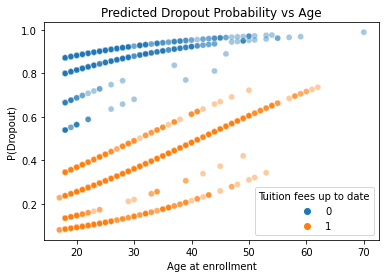

Not current: 0.861, Current: 0.248, Difference: 0.613


In [35]:
##2.3
df["pred_prob"] = model.predict_proba(X)[:, 1]

sns.scatterplot(data=df, x="Age at enrollment", y="pred_prob",
                hue="Tuition fees up to date", alpha=0.4)
plt.title("Predicted Dropout Probability vs Age")
plt.ylabel("P(Dropout)")
plt.show()

#average difference in predicted probability by tuition status
not_current = df[df["Tuition fees up to date"] == 0]["pred_prob"].mean()
current     = df[df["Tuition fees up to date"] == 1]["pred_prob"].mean()
print(f"Not current: {not_current:.3f}, Current: {current:.3f}, Difference: {not_current - current:.3f}")
#being current on tuition reduces predicted dropout probability most for middle-aged students

In [36]:
##2.4
preds = model.predict(X)
print(confusion_matrix(y, preds))
print("Accuracy:", accuracy_score(y, preds))

[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


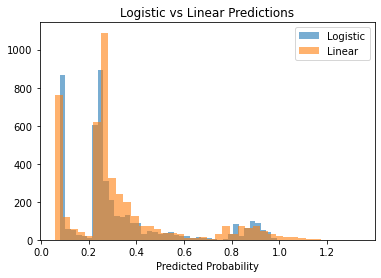

In [37]:
##2.5
lin = LinearRegression()
lin.fit(X, y)
lin_preds = lin.predict(X)

plt.hist(df["pred_prob"], bins=40, alpha=0.6, label="Logistic")
plt.hist(lin_preds,       bins=40, alpha=0.6, label="Linear")
plt.xlabel("Predicted Probability")
plt.title("Logistic vs Linear Predictions")
plt.legend()
plt.show()
#the linear model produces values outside [0,1], logistic regression stays bounded

In [38]:
##2.6
##students most at risk: have debt, tuition not up to date, no scholarship, older at enrollment
##interventions: helping students who are behind on tuition by financial aid, payment plan, etc

In [39]:
##2.7
X_multi = df[["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]]
y_multi = df["Target"]

multi = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi.fit(X_multi, y_multi)

preds_multi = multi.predict(X_multi)
print(confusion_matrix(y_multi, preds_multi, labels=multi.classes_))
print("Accuracy:", accuracy_score(y_multi, preds_multi))
print("Classes predicted:", set(preds_multi))

proba_multi = multi.predict_proba(X_multi)
print(pd.DataFrame(proba_multi, columns=multi.classes_).head())
# hard classification may not predict every class
# predicted probabilities assign nonzero values to all three classes for every student

# I used ai to confirm my understanding here

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
Accuracy: 0.7045660036166366
Classes predicted: {'Graduate', 'Dropout'}
    Dropout  Enrolled  Graduate
0  0.680381  0.210525  0.109094
1  0.695836  0.145785  0.158379
2  0.953053  0.041135  0.005812
3  0.117830  0.176979  0.705190
4  0.184228  0.212651  0.603121


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [40]:
##3.1 load and clean data
cdf = pd.read_csv("scratchpad/data/cirrhosis.csv")

cdf = cdf[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]

print(cdf.isnull().sum())
cdf = cdf.dropna()

#binary target: 1 = alive, 0 = dead
cdf["alive"] = (cdf["Status"] != "D").astype(int)

#encode categoricals
cdf_enc = pd.get_dummies(cdf[["Edema", "Drug", "Bilirubin"]], drop_first=True)

Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


In [41]:
##3.2 logistic regression
X3 = cdf_enc
y3 = cdf["alive"]

model3 = LogisticRegression(max_iter=1000)
model3.fit(X3, y3)

print(dict(zip(X3.columns, model3.coef_[0])))
#drug has positive coef -> D-penicillamine improves survival vs placebo
#bilirubin has negative coef -> higher bilirubin = lower survival
#edema S and Y have negative coefs -> edema reduces survival, worse with Y
##used ai to help gain a more extensive understanding

{'Bilirubin': -0.3513827452654867, 'Edema_S': -0.4511768603567679, 'Edema_Y': -1.6104984197325827, 'Drug_Placebo': 0.2310386751611308}


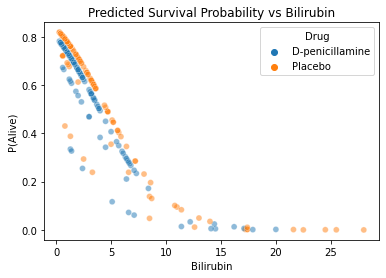

Drug: 0.590, Placebo: 0.609, Difference: -0.019


In [42]:
##3.3 predicted probabilities and scatter plot
cdf["pred_prob"] = model3.predict_proba(X3)[:, 1]

sns.scatterplot(data=cdf, x="Bilirubin", y="pred_prob", hue="Drug", alpha=0.5)
plt.title("Predicted Survival Probability vs Bilirubin")
plt.ylabel("P(Alive)")
plt.show()

drug_avg    = cdf[cdf["Drug"] == "D-penicillamine"]["pred_prob"].mean()
placebo_avg = cdf[cdf["Drug"] == "Placebo"]["pred_prob"].mean()
print(f"Drug: {drug_avg:.3f}, Placebo: {placebo_avg:.3f}, Difference: {drug_avg - placebo_avg:.3f}")
#drug seems to help most at lower bilirubin values where survival probability is still high

In [43]:
##3.4 confusion matrix and accuracy
preds3 = model3.predict(X3)
print(confusion_matrix(y3, preds3))
print("Accuracy:", accuracy_score(y3, preds3))

[[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


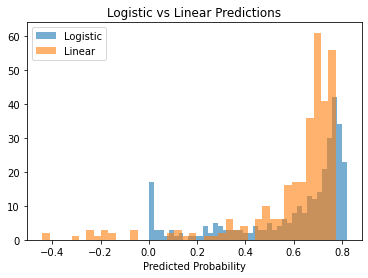

In [44]:
##3.5 linear model comparison
lin3 = LinearRegression()
lin3.fit(X3, y3)
lin_preds3 = lin3.predict(X3)

plt.hist(cdf["pred_prob"], bins=40, alpha=0.6, label="Logistic")
plt.hist(lin_preds3,       bins=40, alpha=0.6, label="Linear")
plt.xlabel("Predicted Probability")
plt.title("Logistic vs Linear Predictions")
plt.legend()
plt.show()
#same issue as 2.5: linear model predicts out of bounds values

In [45]:
##3.6 multinomial logistic regression on Stage
X3m = pd.get_dummies(cdf[["Edema", "Bilirubin"]], drop_first=True)
y3m = cdf["Stage"].astype(int)

multi3 = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi3.fit(X3m, y3m)

preds_stage = multi3.predict(X3m)
print(confusion_matrix(y3m, preds_stage, labels=multi3.classes_))
print("Accuracy:", accuracy_score(y3m, preds_stage))
print("Classes predicted:", set(preds_stage))

proba_stage = multi3.predict_proba(X3m)
print(pd.DataFrame(proba_stage, columns=multi3.classes_).head())
# hard classification likely only predicts 1-2 dominant stages
# predicted probabilities spread mass across all 4 stages for every patient

[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]
Accuracy: 0.4326923076923077
Classes predicted: {3, 4}
          1         2         3         4
0  0.000013  0.032507  0.143369  0.824111
1  0.072453  0.251637  0.397464  0.278446
2  0.029281  0.181629  0.395812  0.393279
3  0.023287  0.176870  0.397336  0.402507
4  0.020225  0.225025  0.423302  0.331448


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

** Uploading a photo to the repo**

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 